In [1]:
import warnings

# Suppress all DeprecationWarnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Suppress all UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from torch_geometric.data import Data
import torch
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader

/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Parse SMILES into molecular graphs

In [3]:
df_acenes = pd.read_csv('mol_datasets/acenes.csv')
df_acenes = df_acenes.drop(columns=["Unnamed: 0"])
df_acenes.head()

,SMILES,ERE,HRE,rings,fused,bridged,F,S,O,Si,N
0,c1ccc2c(c1)ccc1ccccc12,0.316194,0.218750,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
1,c1ccc2cc3cc4c(ccc5cc6cc7ccccc7cc6cc54)cc3cc2c1,0.148908,0.065630,7.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0
2,c1ccc2cc3c(ccc4c3ccc3c5cc6ccccc6cc5ccc34)cc2c1,0.125509,0.129530,7.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0
3,c1ccc2c(c1)ccc1cc3c4ccccc4c4ccccc4c3cc12,0.180891,0.153495,6.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0
4,c1ccc2ccccc2c1,0.260865,0.186561,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


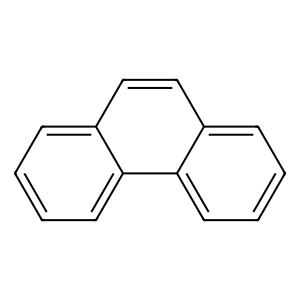

In [4]:
# Example usage
smiles = list(df_acenes['SMILES'].values)[0]
hre = list(df_acenes['HRE'].values)[0]

mol = Chem.MolFromSmiles(smiles)
img = Draw.MolsToGridImage([mol], molsPerRow=1, subImgSize=(300,300))
img

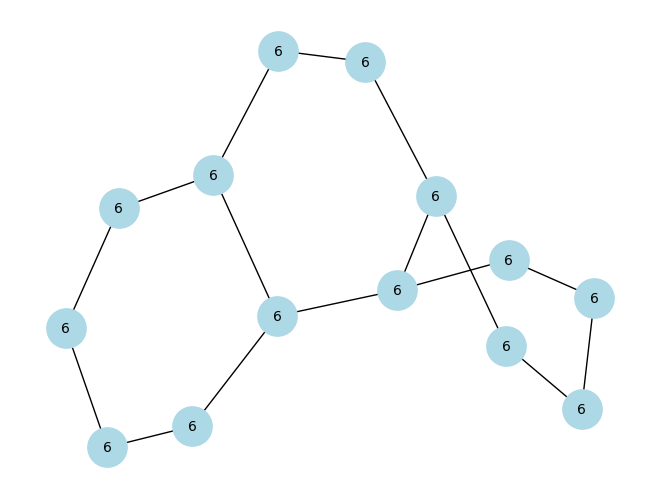

In [5]:
def smiles_to_graph(smiles, energy):
    mol = Chem.MolFromSmiles(smiles)
    x = torch.tensor([atom.GetAtomicNum() for atom in mol.GetAtoms()],
                     dtype=torch.long).unsqueeze(1)
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append((i, j))
        edge_index.append((j, i)) 
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    y = torch.tensor([energy], dtype=torch.float)
    return Data(x=x, edge_index=edge_index, y=y)

def visualize_graph(data): # draw molecules with NetworkX
    G = nx.Graph()
    edge_index = data.edge_index.numpy()
    for i, j in edge_index.T:
        G.add_edge(i, j)
    labels = {i: int(data.x[i].item()) for i in range(data.num_nodes)}
    pos = nx.spring_layout(G)  # layout algorithm
    nx.draw(G, pos, with_labels=True, labels=labels,
            node_color="lightblue", node_size=800, font_size=10)
    plt.show()

g = smiles_to_graph(smiles, hre)
visualize_graph(g)

In [6]:
graphs = []
for _, row in df_acenes.iterrows():
    g = smiles_to_graph(row['SMILES'], row['HRE'])
    graphs.append(g)

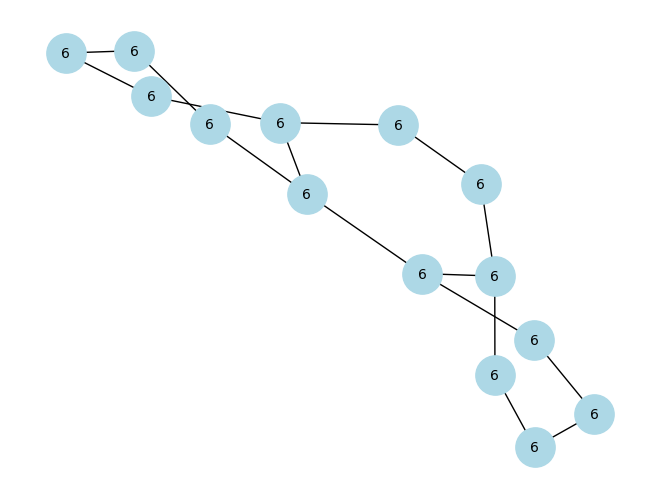

In [7]:
class MoleculeDataset(InMemoryDataset):
    def __init__(self, graphs, transform=None, pre_transform=None):
        super().__init__(None, transform, pre_transform)
        self.data, self.slices = self.collate(graphs)

    def get(self, idx):
        return super().get(idx)

dataset = MoleculeDataset(graphs)
visualize_graph(dataset[0]) # first graph

In [8]:
class SMILESDataset(InMemoryDataset):
    def __init__(self, smiles_list, energies, transform=None, pre_transform=None):
        super().__init__(None, transform, pre_transform)
        graphs = [smiles_to_graph(s, e) for s, e in zip(smiles_list, energies)]
        self.data, self.slices = self.collate(graphs)

    def get(self, idx):
        return super().get(idx)
    
dataset = SMILESDataset(df_acenes['SMILES'].tolist(), df_acenes['HRE'].tolist())

In [9]:
ATOM_MAP = {0:"C", 1:"S"}
BOND_MAP = {
    0: Chem.BondType.SINGLE,
    1: Chem.BondType.DOUBLE,
    2: Chem.BondType.AROMATIC,
    # 3: Chem.BondType.TRIPLE,
}

# import torch
# from torch_geometric.data import Data
# from rdkit import Chem

def smiles_to_ptcfm(smiles, energy):
    mol = Chem.MolFromSmiles(smiles)

    # Atom codes → one-hot
    atom_types = ["C", "S", "Other"]
    x = []
    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 6: code = 0   # C
        elif atom.GetAtomicNum() == 16: code = 1 # S
        else: code = 2                          # Other
        one_hot = [0]*len(atom_types)
        one_hot[code] = 1
        x.append(one_hot)
    x = torch.tensor(x, dtype=torch.float)

    # Bond codes → one-hot
    bond_types = ["SINGLE", "DOUBLE", "AROMATIC", "TRIPLE"]
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [(i, j), (j, i)]
        if bond.GetBondType() == Chem.BondType.SINGLE: code = 0
        elif bond.GetBondType() == Chem.BondType.DOUBLE: code = 1
        elif bond.GetBondType() == Chem.BondType.AROMATIC: code = 2
        elif bond.GetBondType() == Chem.BondType.TRIPLE: code = 3
        else: code = 0
        one_hot = [0]*len(bond_types)
        one_hot[code] = 1
        edge_attr += [one_hot, one_hot]
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # Target: float energy for regression
    y = torch.tensor([float(energy)], dtype=torch.float)

    return Data(edge_index=edge_index, x=x, edge_attr=edge_attr, y=y)

In [10]:
graphs = [smiles_to_ptcfm(row['SMILES'], row['HRE']) for _, row in df_acenes.iterrows()]

In [11]:
graphs[0]

Data(x=[14, 3], edge_index=[2, 32], edge_attr=[32, 4], y=[1])

In [12]:
import qek.data.graphs as qek_graphs
from pathlib import Path
import qek.data.extractors as qek_extractors

compiler = qek_graphs.PTCFMCompiler()

# Use the Qutip Extractor.
extractor = qek_extractors.QutipExtractor(
    # Once computing is complete, data will be saved in this file.
    path=Path("saved_data.json"),
    compiler=compiler
)

# Add the graphs using the compiler we've picked previously.
extractor.add_graphs(graphs=graphs)

# We may now compile them.
compiled = extractor.compile()
display("Compiled %s sequences" % (len(compiled), ))

graph # 30 is not embeddable, skipping
graph # 31 is not embeddable, skipping
graph # 32 is not embeddable, skipping
graph # 33 is not embeddable, skipping
graph # 35 is not embeddable, skipping
graph # 36 is not embeddable, skipping
graph # 39 is not embeddable, skipping
graph # 41 is not embeddable, skipping
graph # 42 is not embeddable, skipping
graph # 44 is not embeddable, skipping
graph # 45 is not embeddable, skipping
imported 34 graphs


/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, prefer setting `prefix='q'` when using classmethods, as that will become the new default once `int` qubit IDs become invalid.
  super().__init__(qubits, **kwargs)
/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, prefer setting `prefix='q'` when using classmethods, as that will become the new default once `int` qubit IDs become invalid.
  super().__init__(qubits, **kwargs)
/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, pr

'Compiled 32 sequences'

In [13]:
# On our test computer, the practical limit is around 10 qubits.
max_qubits = 10
processed_dataset = extractor.run(max_qubits=max_qubits).processed_data
display("Extracted features from %s samples"% (len(processed_dataset), ))

Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (14 > 10), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (30 > 10), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (30 > 10), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (26 > 10), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (12 > 10), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (24 > 10), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (24 > 10), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (24 > 10), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (20 > 10), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (12 > 10),

'Extracted features from 4 samples'

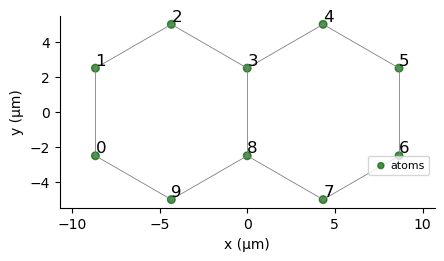

In [15]:
processed_dataset[0].draw_register()